# **Tennis Stroke MultiClassification: Model Development**

## **1. Imports**

In [96]:
import torch
from torch import nn
import torch.nn.functional as F
import albumentations as A
from albumentations import ToTensorV2
import random
from PIL import Image
import os
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import models
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import cv2
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
import pandas as pd
from typing import List, Callable

device = 'mps' if torch.backends.mps.is_available() else 'cpu'
plt.rcParams['font.family'] = 'Serif' 

## **2. Data Processing and Visualizations**

In [2]:
def build_dataframe(root_dir: str) -> pd.DataFrame:
    """Builds pandas Dataframe from data folder."""
    data = []

    for label in sorted(os.listdir(root_dir)): 
        class_dir = os.path.join(root_dir, label)
        if not os.path.isdir(class_dir):
            continue  

        for filename in os.listdir(class_dir):
            file_path = os.path.join(class_dir, filename)

            data.append({
                "filepath": file_path,
                "filename": filename,
                "label": label
            })

    return pd.DataFrame(data)

df = build_dataframe("image_data")
df.shape

(2000, 3)

In [3]:
def split_data(df: pd.DataFrame, test_split: float = 0.25, label_column: str = 'label') -> pd.DataFrame:
    """Splits data into a train/test split. Default is 25% train set. Stratisfies by label column."""
    train_df, test_df = train_test_split(df, test_size = test_split, stratify = df[label_column])
    return train_df, test_df

train_df, test_df = split_data(df)
train_df.shape, test_df.shape

((1500, 3), (500, 3))

In [ ]:
# Save Dataframes
if not os.path.exists("dataframe"):
    os.mkdir("dataframe")
train_df.to_csv('dataframe/train_df.csv')
test_df.to_csv('dataframe/test_df.csv')

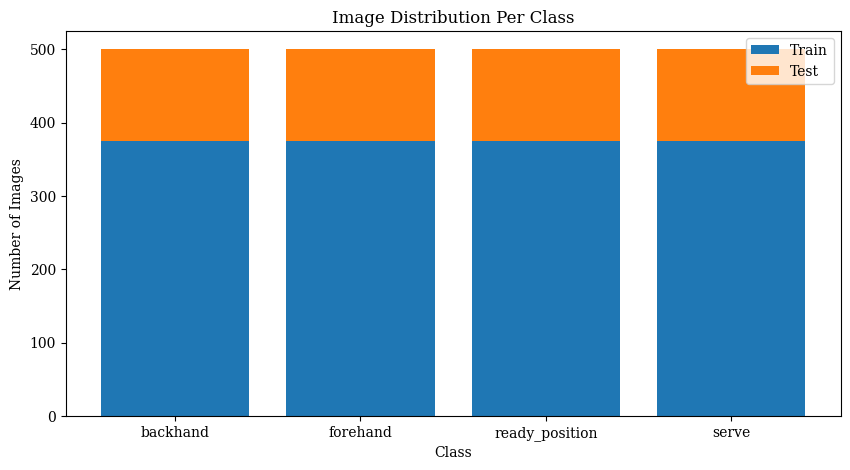

In [97]:
def plot_stacked_distribution(train_df, test_df, label_column = 'label'):
    """Plots the distribution of the training and testing sets."""
    train_counts = train_df[label_column].value_counts().sort_index()
    test_counts = test_df[label_column].value_counts().sort_index()

    labels = train_counts.index.tolist()

    plt.figure(figsize = (10, 5))
    plt.bar(labels, train_counts.values, label = 'Train')
    plt.bar(labels, test_counts.values, bottom = train_counts.values, label = 'Test')

    plt.title("Image Distribution Per Class")
    plt.xlabel("Class")
    plt.ylabel("Number of Images")
    plt.legend()
    plt.savefig('assets/image_distribution.png')
    plt.show()

plot_stacked_distribution(train_df, test_df)

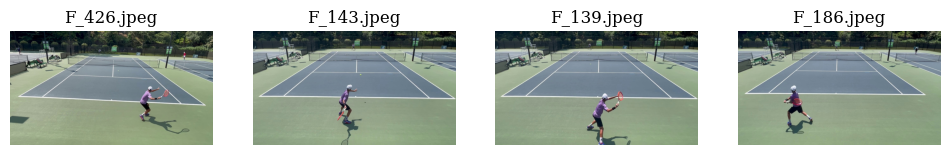

In [102]:
def show_random_images(folder_path: str, num_images: int = 4) -> None:
    files = [f for f in os.listdir(folder_path) if f.lower().endswith((".jpg", ".png", ".jpeg"))]
    
    sample_files = random.sample(files, num_images)

    plt.figure(figsize = (12, 4))
    for i, filename in enumerate(sample_files):
        img = Image.open(os.path.join(folder_path, filename))
        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(filename[:15])
        plt.axis("off")
    plt.savefig('assets/original_images', bbox_inches = 'tight')
    plt.show()

show_random_images("image_data/forehand")

## **3. Data Loading, Transformations, and Dataset Definition**

In [5]:
def center_crop_square(image, **kwargs):
    h, w = image.shape[:2]
    min_dim = min(h, w)
    top = (h - min_dim) // 2
    left = (w - min_dim) // 2
    return image[top : top + min_dim, left:left + min_dim]

In [6]:
# Transformation Definitions
mean, std = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

# 1: Normal transforms, No Aspect Ratio Preservation
train_transforms_1 = A.Compose([
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 2: Normal transforms, Preserves Aspect Ratio
train_transforms_2 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 3: Normal transforms, Preserves Aspect Ratio, Flips Horizantally
train_transforms_3 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.HorizontalFlip(p = 1),
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 4: Normal transforms, Aspect Ratio not Preserved, + or - 20 percent zoom
train_transforms_4 = A.Compose([
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Affine(
        scale = (1 - 0.2, 1 + 0.2),        
        fit_output = False,
        border_mode = 0,
        p = 1
    ),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 5: Normal transforms, Aspect Ratio Preserved, + or - 20 percent translate
train_transforms_5 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Affine(
        translate_percent = (-0.2, 0.2),        
        fit_output = False,
        border_mode = 0,
        p = 1
    ),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 6: Normal transforms, Aspect Ratio Preserved, + or - 20% zoom, + or - 20% translate
train_transforms_6 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.HorizontalFlip(p = 1),
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Affine(
        scale = (1 - 0.2, 1 + 0.2),    
        translate_percent = (-0.2, 0.2),       
        fit_output = False,
        border_mode = 0,
        p = 1
    ),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

# 7: Normal transforms, Aspect Ratio Preserved, + or - 10% rotation
train_transforms_7 = A.Compose([
    A.Lambda(image = center_crop_square),
    A.Rotate(limit = 10, p = 1),
    A.RandomBrightnessContrast(brightness_limit = 0.1, contrast_limit = 0.1, p = 0.5),
    A.HueSaturationValue(hue_shift_limit = 10, sat_shift_limit = 10, val_shift_limit = 10, p = 0.5),
    A.OneOf([ 
        A.GaussianBlur(blur_limit = (3, 5), p = 1.0),
        A.Sharpen(alpha = (0.1, 0.3), lightness = (0.7, 1.0), p = 1.0),
    ], p = 0.3),
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

train_transforms = [train_transforms_1, train_transforms_2, train_transforms_3,
                    train_transforms_4, train_transforms_5, train_transforms_6, train_transforms_7]

# Test transforms: Preserved Aspect Ratio and resize
test_transform = A.Compose([
    A.Lambda(image = center_crop_square), 
    A.Resize(224, 224),
    A.Normalize(mean = mean, std = std),
    ToTensorV2()
])

In [7]:
# Dataset Definition
label_map = {
    'backhand': 0,
    'forehand': 1,
    'ready_position': 2,
    'serve': 3
}

class TennisStrokeDataset(Dataset):
    def __init__(self, df: pd.DataFrame, transform: A.transforms, label_map: dict):
        """
        df: Pandas DataFrame containing 'filepath' and 'label'
        transform: Albumentations transform
        label_map: dict mapping label string -> int
        """
        self.df = df.reset_index(drop = True)
        self.transform = transform
        self.label_map = label_map

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # Load image (H, W, C) in BGR format
        img = cv2.imread(row['filepath'])
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert to RGB

        # Apply transformations
        img = self.transform(image = img)['image']

        # Convert label from string to int
        label = self.label_map[row['label']]
        label = torch.tensor(label, dtype = torch.long)

        return img, label

In [8]:
train_df.columns

Index(['filepath', 'filename', 'label'], dtype='object')

In [9]:
def create_image_dataloaders(
    train_df: pd.DataFrame,
    test_df: pd.DataFrame,
    train_transforms: List[Callable[[Image.Image], torch.Tensor]],
    test_transform: Callable[[Image.Image], torch.Tensor],
    label_map: dict,
    batch_size: int = 32,
    seed: int = 73,
):
    """
        Creates a training and testing dataset from 1 Pandas Dataframe

        Params:
            train_df: Training Pandas DataFrame containing ['filepath', 'filename', 'label'] columns
            test_df: Testing Pandas DataFrame containing ['filepath', 'filename', 'label'] columns
            train_transforms: List of training set transformations
            test_transform: Testing set transformations
            batch_size: DataLoader batch size, default = 32
            seed: Manual Seed value, default = 73

        Returns 2 DataLoaders
            train_dataloader, test_dataloader
    """

    # Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)

    # Create training datasets for each tranform and concatenate the sets
    train_datasets = [
        TennisStrokeDataset(
            df = train_df,
            transform = tfm,
            label_map = label_map
        ) for tfm in train_transforms
    ]

    if len(train_datasets) > 1:
        train_dataset = ConcatDataset(train_datasets)
    else:
        train_dataset = train_datasets[0]

    # Testing Set
    test_dataset = TennisStrokeDataset(
            df = test_df,
            transform = test_transform,
            label_map = label_map
    )

    # DataLoaders
    train_loader = DataLoader(train_dataset, batch_size = batch_size, shuffle = True, drop_last = False)
    test_loader = DataLoader(test_dataset, batch_size = batch_size, shuffle = False, drop_last = False)

    return train_loader, test_loader

train_dataloader, test_dataloader = create_image_dataloaders(train_df, test_df, train_transforms, test_transform, 
                                                         label_map = label_map)

len(train_dataloader), len(test_dataloader)

(329, 16)

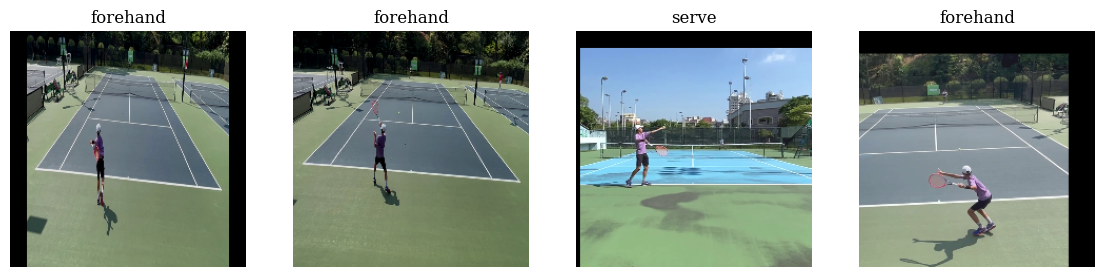

In [101]:
#Visualize some samples from the dataloader
idx_to_class = {v: k for k, v in label_map.items()}
def unnormalize(img_tensor: torch.Tensor) -> Image.Image:
    """Unnormalize Tensor Values."""
    img = img_tensor.permute(1, 2, 0).cpu().numpy()  
    img = (img * std) + mean           
    img = np.clip(img, 0, 1)      
    return img

def visualize_batch(data_loader: torch.utils.data.DataLoader, num_images = 4):
    """Visualize 4 Images from a Dataloader"""
    images, labels = next(iter(data_loader))

    plt.figure(figsize = (14, 4))
    for i in range(num_images):
        img = unnormalize(images[i])
        label = idx_to_class[labels[i].item()] 

        plt.subplot(1, num_images, i + 1)
        plt.imshow(img)
        plt.title(label)
        plt.axis("off")
    
    plt.savefig('assets/post_augmentations.png', bbox_inches = 'tight')
    plt.show()

visualize_batch(train_dataloader)

## **4. Initialize Model, Optimizer, and Loss Function**

In [ ]:
class FocalLoss(nn.Module):
    """
    Multiclass Focal Loss implementation.
    Works with softmax logits (for CrossEntropy-style classification).
    """
    def __init__(self, alpha: List[float], gamma: float = 2.0):
        """
        Args:
            alpha: List of weighting factor for class imbalance
            gamma: Focusing parameter
        """
        super().__init__()
        self.alpha = torch.tensor(alpha, dtype = torch.float32)
        self.gamma = gamma

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        """
        Args:
            logits: model outputs before softmax, shape (N, C)
            targets: ground-truth class indices
        """
        # Logits to probabilities
        probs = F.softmax(logits, dim = 1)
        pt = probs.gather(1, targets.unsqueeze(1)).squeeze(1)

        # Select alpha value
        alpha_t = self.alpha.to(logits.device)[targets]

        # Compute focal loss
        focal_term = (1 - pt) ** self.gamma
        loss = -alpha_t * focal_term * torch.log(pt + 1e-8)

        return loss.mean()

In [ ]:
def create_mobilenet_v3(num_classes: int, weights = "IMAGENET1K_V1"):
    model = models.mobilenet_v3_small(weights = weights)
    in_features = model.classifier[3].in_features
    model.classifier[3] = nn.Linear(in_features, num_classes)
    return model

def create_resnet18(num_classes: int, weights = "IMAGENET1K_V1"):
    model = models.resnet18(weights = weights)
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model

def create_convnext_tiny(num_classes: int, weights = "IMAGENET1K_V1"):
    model = models.convnext_tiny(weights = weights)
    in_features = model.classifier[2].in_features
    model.classifier[2] = nn.Linear(in_features, num_classes)
    return model

mobilenet_v3_model = create_mobilenet_v3(num_classes = 4)
resnet18_model = create_resnet18(num_classes = 4)
convnext_model = create_convnext_tiny(num_classes = 4)

mobilenet_v3_model.to(device)
resnet18_model.to(device)
convnext_model.to(device)

In [12]:
def accuracy_function(y_true: torch.Tensor, y_pred_logits: torch.Tensor) -> float:
    """
    Computes accuracy for multiclass tasks.
    Args:
        y_true: Ground truth labels
        y_pred_logits: Model logit outputs
    """
    preds = torch.argmax(y_pred_logits, dim = 1)  # shape (N,)
    return (preds == y_true).float().mean().item() * 100

In [18]:
adam_optimizer_mobilenetv3 = torch.optim.Adam(params = mobilenet_v3_model.parameters(), lr = 1e-4)
adam_optimizer_resnet18 = torch.optim.Adam(params = resnet18_model.parameters(), lr = 1e-4)
adam_optimizer_convnext = torch.optim.Adam(params = convnext_model.parameters(), lr = 1e-4)
loss_fn = FocalLoss(alpha = [1.0, 1.0, 1.0, 1.0], gamma = 2.0)

# **5. Training and Testing Loop, Model and Results Saving**

In [ ]:
import os
import pickle
from typing import Dict, Any

def save_results_pickle(results_dict: Dict[str, Any], filename: str, save_dir: str = 'results-models') -> None:
    """
    Saves the output dictionary of training_testing_loop() into a pickle file.

    Args:
        results_dict (dict): Output from training_testing_loop()
        save_dir (str): Directory to save results into
        filename (str): Name of the pickle file
    """
    os.makedirs(save_dir, exist_ok = True)

    # Full path to save file
    filepath = os.path.join(save_dir, filename)

    # Save dictionary to pickle
    with open(filepath, "wb") as f:
        pickle.dump(results_dict, f)

In [ ]:
def save_model_weights(model: nn.Module, filename: str, save_dir: str = 'results-models') -> None:
    """
    Saves a PyTorch model's weights (state_dict) to a specified directory.

    Args:
        model (nn.Module): Trained PyTorch model
        save_dir (str): Directory to save model weights into (default: results-models)
        filename (str): Filename for the weights
    """
    os.makedirs(save_dir, exist_ok = True)

    filepath = os.path.join(save_dir, filename)

    torch.save(model.state_dict(), filepath)

In [24]:
def training_testing_loop(
        model: torch.nn.Module,
        model_name: str,
        train_dataloader: torch.utils.data.DataLoader,
        test_dataloader: torch.utils.data.DataLoader,
        device: str,
        max_epochs: int,
        optimizer: torch.optim.Optimizer,
        loss_function: torch.nn.Module,
        accuracy_function: Callable[[torch.Tensor, torch.Tensor], float] = accuracy_function,
        seed: int = 73,
) -> dict:
    """
    Training and Testing Loop

    Args:
        model: PyTorch model
        model_name: Name of the model (for saving weights)
        train_dataloader: Dataloader containing training set
        test_dataloader: Dataloader containing testation set
        device: cuda or cpu or mps
        max_epochs: number of epochs
        optimizer: Optimization Functions
        accuracy_function: Calculates accuracy
        optimzer: Optimization function
        seed: For reproducibility
    """
    # Set seed
    torch.manual_seed(seed)

    # 4 Lists to keep track of train/test accuracy/loss.
    train_loss, test_loss, train_accuracy, test_accuracy = [], [], [], []

    # Move model to proper device
    model.to(device)

    # Keep track of the best test loss
    best_test_loss = float("inf")

    for epoch in range(max_epochs):
        # ------------------------ Training ------------------------------
        model.train()

        # Keep track of total loss and accuracy and divide by batch size at the end of every epoch
        total_train_loss, total_train_accuracy = 0, 0

        for X_batch_images, y_batch_labels in train_dataloader:
            X_batch_images = X_batch_images.to(device)
            
            y_batch_labels = y_batch_labels.long().to(device)

            optimizer.zero_grad()
            y_train_pred_logits = model(X_batch_images)
            loss = loss_function(y_train_pred_logits, y_batch_labels)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            total_train_accuracy += accuracy_function(y_batch_labels.squeeze(), y_train_pred_logits)

        # Calculate train loss and accuracy over the epoch
        avg_train_loss = total_train_loss / len(train_dataloader)
        avg_train_acc = total_train_accuracy / len(train_dataloader)

        # ----------------------- Testing ---------------------------
        # Set model to evaluation mode for testing
        model.eval()
        total_test_loss, total_test_accuracy = 0, 0
        test_preds, test_targets = [], []

        with torch.inference_mode():
            for X_batch_images, y_batch_labels in test_dataloader:
                X_batch_images = X_batch_images.to(device)

                y_batch_labels = y_batch_labels.long().to(device)

                y_test_pred_logits = model(X_batch_images)
                loss = loss_function(y_test_pred_logits, y_batch_labels)
                total_test_loss += loss.item()
                total_test_accuracy += accuracy_function(y_batch_labels.squeeze(), y_test_pred_logits)

                preds = torch.argmax(y_test_pred_logits, dim = 1)
                test_preds.extend(preds.cpu().tolist())
                test_targets.extend(y_batch_labels.cpu().tolist())

            avg_test_loss = total_test_loss / len(test_dataloader)
            avg_test_acc = total_test_accuracy / len(test_dataloader)

        print(f"========== Epoch [{epoch + 1}/{max_epochs}] ============")
        print(f"Train Loss: {avg_train_loss:.4f} | Test Loss: {avg_test_loss:.4f}")
        print(f"Train Acc:  {avg_train_acc:.4f}% | Test Acc:  {avg_test_acc:.4f}%\n")

        if avg_test_loss < best_test_loss:
            best_test_loss = avg_test_loss
            save_model_weights(model, filename = f"{model_name}.pth")
            print(f"✅ Best model saved at epoch {epoch+1} with test loss {avg_test_loss:.4f}")

        # Append losses and accuracies
        train_loss.append(avg_train_loss)
        test_loss.append(avg_test_loss)
        train_accuracy.append(avg_train_acc)
        test_accuracy.append(avg_test_acc)

    return {
        "train_loss": train_loss,
        "test_loss": test_loss,
        "train_accuracy": train_accuracy,
        "test_accuracy": test_accuracy,
        "test_preds": test_preds,
        "test_targets": test_targets
    }

In [26]:
mobilenetv3_small_results = training_testing_loop(
    mobilenet_v3_model, 
    'mobilenet_v3',
    train_dataloader, 
    test_dataloader, 
    device, 
    max_epochs = 6, 
    optimizer = adam_optimizer_mobilenetv3,
    loss_function = loss_fn,
    accuracy_function = accuracy_function
    )

========== Epoch [1/6] ============
Train Loss: 0.3188 | Test Loss: 0.1072
Train Acc:  71.1626% | Test Acc:  88.4375%

✅ Best model saved at epoch 1 with test loss 0.1072
========== Epoch [2/6] ============
Train Loss: 0.1237 | Test Loss: 0.0602
Train Acc:  86.6166% | Test Acc:  93.9062%

✅ Best model saved at epoch 2 with test loss 0.0602
========== Epoch [3/6] ============
Train Loss: 0.0866 | Test Loss: 0.0654
Train Acc:  90.2451% | Test Acc:  92.4219%

========== Epoch [4/6] ============
Train Loss: 0.0665 | Test Loss: 0.0875
Train Acc:  92.0403% | Test Acc:  92.4219%

========== Epoch [5/6] ============
Train Loss: 0.0551 | Test Loss: 0.0538
Train Acc:  93.8450% | Test Acc:  94.1797%

✅ Best model saved at epoch 5 with test loss 0.0538
========== Epoch [6/6] ============
Train Loss: 0.0473 | Test Loss: 0.0627
Train Acc:  94.4244% | Test Acc:  93.0469%



In [28]:
save_results_pickle(mobilenetv3_small_results, 'mobilenetv3.pkl')

In [29]:
resnet18_results = training_testing_loop(
    resnet18_model, 
    'resnet18',
    train_dataloader, 
    test_dataloader, 
    device, 
    max_epochs = 6, 
    optimizer = adam_optimizer_resnet18,
    loss_function = loss_fn,
    accuracy_function = accuracy_function
    )

========== Epoch [1/6] ============
Train Loss: 0.1606 | Test Loss: 0.1042
Train Acc:  84.8404% | Test Acc:  88.5156%

✅ Best model saved at epoch 1 with test loss 0.1042
========== Epoch [2/6] ============
Train Loss: 0.0539 | Test Loss: 0.0759
Train Acc:  94.3104% | Test Acc:  93.3203%

✅ Best model saved at epoch 2 with test loss 0.0759
========== Epoch [3/6] ============
Train Loss: 0.0373 | Test Loss: 0.0735
Train Acc:  95.9252% | Test Acc:  92.9297%

✅ Best model saved at epoch 3 with test loss 0.0735
========== Epoch [4/6] ============
Train Loss: 0.0316 | Test Loss: 0.0782
Train Acc:  96.2956% | Test Acc:  94.1016%

========== Epoch [5/6] ============
Train Loss: 0.0240 | Test Loss: 0.0478
Train Acc:  97.5019% | Test Acc:  94.9609%

✅ Best model saved at epoch 5 with test loss 0.0478
========== Epoch [6/6] ============
Train Loss: 0.0232 | Test Loss: 0.0781
Train Acc:  97.5114% | Test Acc:  93.0469%



In [30]:
save_results_pickle(resnet18_results, 'resnet18.pkl')

In [31]:
convnext_results = training_testing_loop(
    convnext_model, 
    'convnext',
    train_dataloader, 
    test_dataloader, 
    device, 
    max_epochs = 6, 
    optimizer = adam_optimizer_convnext,
    loss_function = loss_fn,
    accuracy_function = accuracy_function
    )

========== Epoch [1/6] ============
Train Loss: 0.1297 | Test Loss: 0.0642
Train Acc:  87.6520% | Test Acc:  94.2969%

✅ Best model saved at epoch 1 with test loss 0.0642
========== Epoch [2/6] ============
Train Loss: 0.0357 | Test Loss: 0.0694
Train Acc:  96.2766% | Test Acc:  94.6875%

========== Epoch [3/6] ============
Train Loss: 0.0240 | Test Loss: 0.0714
Train Acc:  97.4639% | Test Acc:  94.0234%

========== Epoch [4/6] ============
Train Loss: 0.0209 | Test Loss: 0.0750
Train Acc:  97.7109% | Test Acc:  95.3516%

========== Epoch [5/6] ============
Train Loss: 0.0198 | Test Loss: 0.0704
Train Acc:  98.0243% | Test Acc:  93.0469%

========== Epoch [6/6] ============
Train Loss: 0.0167 | Test Loss: 0.0584
Train Acc:  98.3283% | Test Acc:  95.9766%

✅ Best model saved at epoch 6 with test loss 0.0584


In [32]:
save_results_pickle(convnext_results, 'convnext.pkl')

## **6. Model Results, Confusion Matrices**

In [54]:
def load_pickle(path: str) -> Any:
    """Load any Python object from a .pkl file."""
    with open(path, "rb") as f:
        return pickle.load(f)
    
mobilenetv3_results = load_pickle('results-models/mobilenetv3.pkl')
resnet18_results = load_pickle('results-models/resnet18.pkl')
convnext_results = load_pickle('results-models/convnext.pkl')

In [105]:
def plot_training_testing_metrics(results_dict: dict, plot_file_name: str, model_name: str) -> None:
    """
    Plots training and testing metrics given a dictionary containing results

    Args:
        results_dict: Dictionary containing ['train_loss', 'test_loss', 'train_accuracy', 
        'test_accuracy', 'test_preds', 'test_targets']
        model_name: Model name
    """

    # Unpack Dictionary
    train_loss = results_dict.get('train_loss', [])
    test_loss = results_dict.get('test_loss', [])
    train_accuracy = results_dict.get('train_accuracy', [])
    test_accuracy = results_dict.get('test_accuracy', [])

    epochs = range(1, len(train_loss) + 1)

    fig, axes = plt.subplots(1, 2, figsize = (12, 5))

    # ---------- Plot 1: Loss -----------------
    axes[0].plot(epochs, train_loss, label = "Train Loss", color = 'blue', marker = 'o', linewidth = 2.5)
    axes[0].plot(epochs, test_loss, label = "Test Loss", color = 'red', marker = 'o', linewidth = 2.5)
    axes[0].set_title(f"{model_name} Loss", fontsize = 13, weight = 'bold')
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True)

    # ---------- Plot 2: Accuracy -----------------
    axes[1].plot(epochs, train_accuracy, label = "Train Accuracy", color = 'blue', marker = 'o', linewidth = 2.5)
    axes[1].plot(epochs, test_accuracy, label = "Test Accuracy", color = 'red', marker = 'o', linewidth = 2.5)
    axes[1].set_title(f"{model_name} Accuracy", fontsize = 13, weight = 'bold')
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.tight_layout(pad = 0)
    plt.savefig(f'assets/{plot_file_name}', bbox_inches = 'tight')
    plt.show()

In [103]:
def plot_confusion_matrix(results_dict: dict, plot_file_name: str, class_names: list = None, title: str = "Confusion Matrix"):
    """
    Plot a confusion matrix from model validation results.

    Args:
        results_dict: Dictionary containing 'test_preds' and 'test_targets'
        class_names: List of Class Labels
        title: Title of the plot
    """
    # Extract predictions and targets
    y_true = results_dict["test_targets"]
    y_pred = results_dict["test_preds"]

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred)

    cm = cm.astype('float') / cm.sum(axis = 1, keepdims = True) # Normalize
    fmt = ".2f"
    cm_title = f"{title}"

    fig, ax = plt.subplots(figsize = (5, 5))
    disp = ConfusionMatrixDisplay(confusion_matrix = cm, display_labels = class_names)
    disp.plot(cmap = "Blues", ax = ax, values_format = fmt, colorbar = False)
    ax.set_title(cm_title, fontsize = 14, weight = "bold", pad = 12)
    ax.set_xlabel("Predicted Label", fontsize = 12)
    ax.set_ylabel("True Label", fontsize = 12)
    plt.xticks(rotation = 30)
    plt.yticks(rotation = 0)
    plt.tight_layout() 
    plt.savefig(f'assets/{plot_file_name}', bbox_inches = 'tight')
    plt.show()

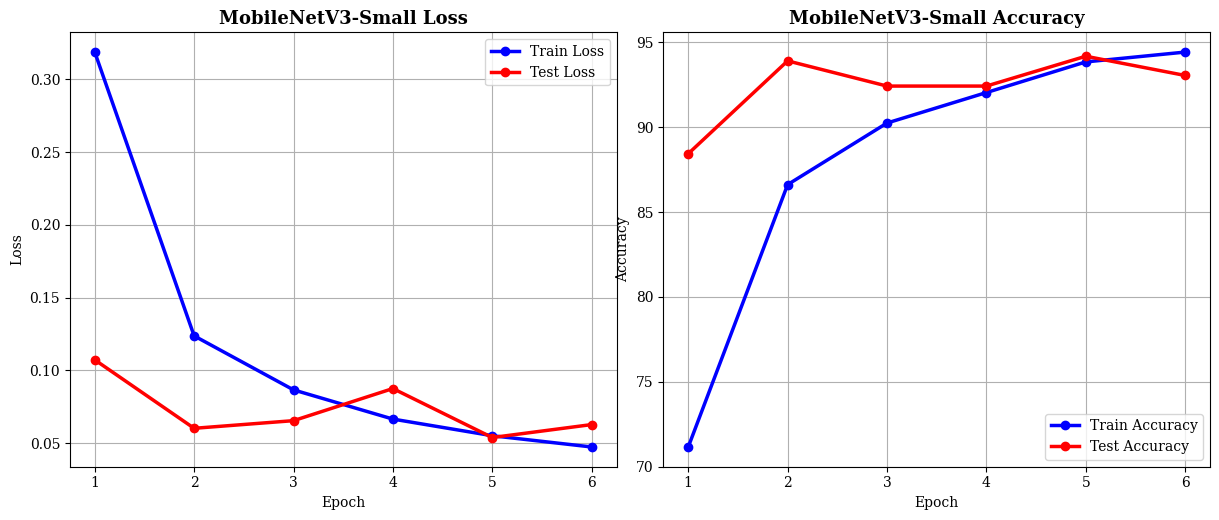

In [106]:
plot_training_testing_metrics(mobilenetv3_results, 'mobilenetv3_plot', 'MobileNetV3-Small')

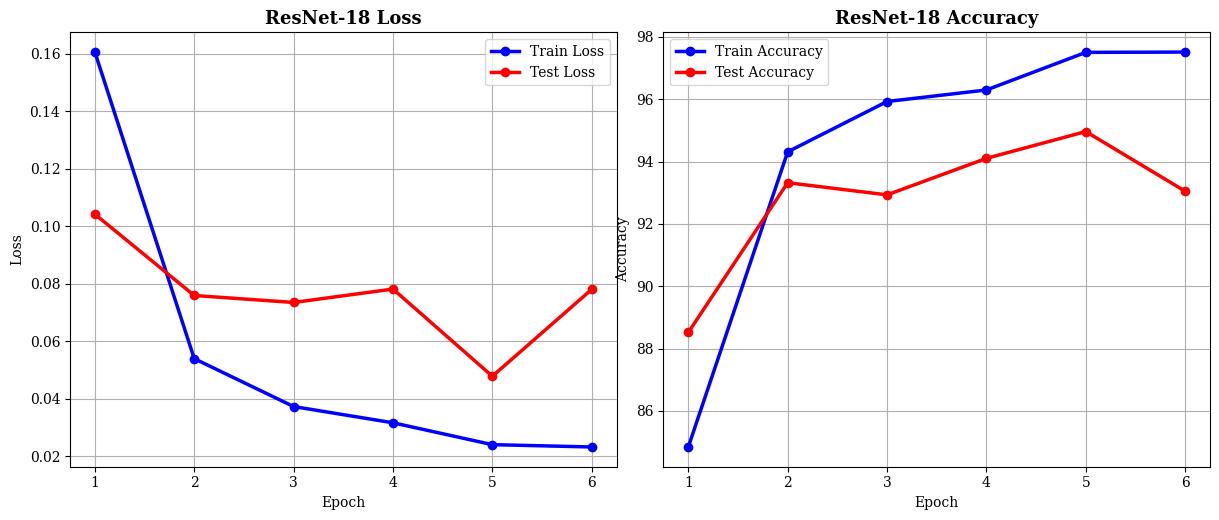

In [108]:
plot_training_testing_metrics(resnet18_results, 'resnet18_plot', 'ResNet-18')

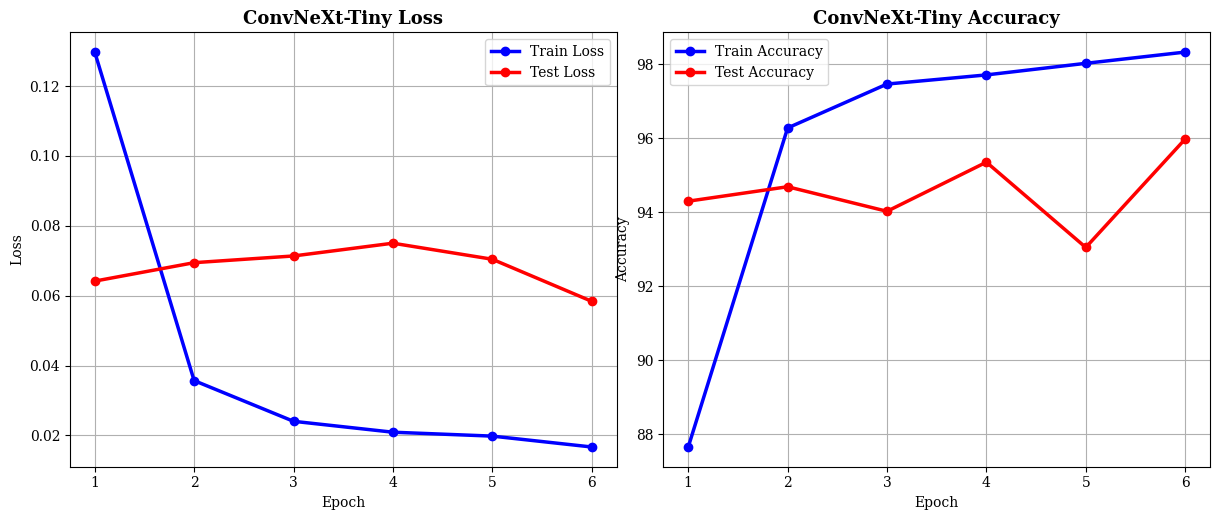

In [109]:
plot_training_testing_metrics(convnext_results, 'convnext_plot', 'ConvNeXt-Tiny')

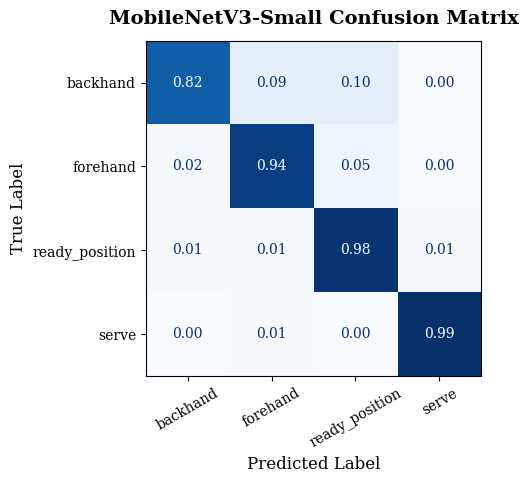

In [110]:
plot_confusion_matrix(mobilenetv3_results, 'mobilenetv3_matrix', class_names = label_map.keys(), title = 'MobileNetV3-Small Confusion Matrix')

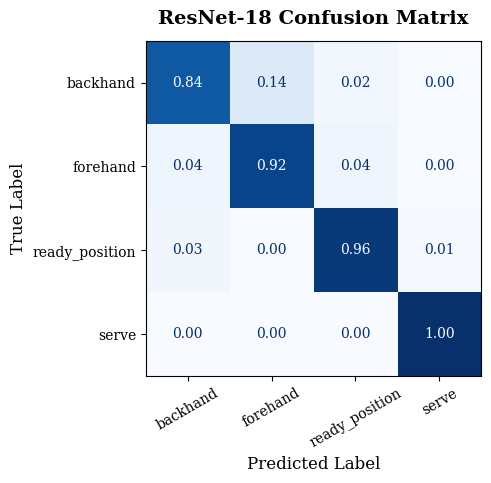

In [111]:
plot_confusion_matrix(resnet18_results, 'resnet18_matrix', class_names = label_map.keys(), title = 'ResNet-18 Confusion Matrix')

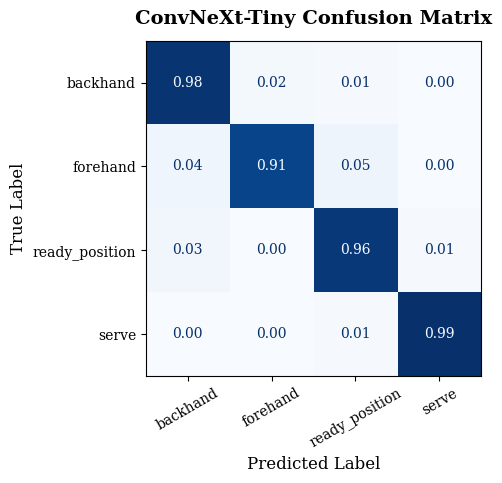

In [112]:
plot_confusion_matrix(convnext_results, 'convnext_matrix', class_names = label_map.keys(), title = 'ConvNeXt-Tiny Confusion Matrix')

## **7. GradCAM Visualizations**

In [ ]:
def get_target_layer(model, model_name: str):
    """Gets the target layer for applying GradCAM."""
    model_name = model_name.lower()
    if "resnet" in model_name:
        return model.layer4[-1]
    elif "convnext" in model_name:
        return model.features[-1]
    elif "mobilenet" in model_name:
        return model.features[-1]
    else:
        raise ValueError(f"Unknown model type for Grad-CAM: {model_name}")
    
def generate_gradcam(model, model_name: str, image_tensor: torch.Tensor, original_img: np.ndarray):
    """Generate GradCAM Heatmap."""
    model.eval()
    target_layer = get_target_layer(model, model_name)
    
    cam = GradCAM(model = model, target_layers = [target_layer])
    grayscale_cam = cam(input_tensor = image_tensor, targets = None)[0] 
    visualization = show_cam_on_image(original_img, grayscale_cam, use_rgb = True)

    return visualization  # returns a heatmap overlay (H, W, 3)

def plot_gradcams(original_img, cam1, cam2, cam3, titles, plot_file):
    """Plots original image, and 3 GradCAM Visualizations."""
    fig, axes = plt.subplots(1, 4, figsize = (18, 5))
    imgs = [original_img, cam1, cam2, cam3]

    for ax, img, title in zip(axes, imgs, titles):
        ax.imshow(img)
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.savefig(plot_file, bbox_inches = 'tight')
    plt.show()

In [70]:
# Recreate Architectures
mobilenet_v3_model = create_mobilenet_v3(num_classes = 4)
resnet18_model = create_resnet18(num_classes = 4)
convnext_model = create_convnext_tiny(num_classes = 4)

In [71]:
# Load Model Weights
mobilenet_v3_model.load_state_dict(torch.load("results-models/mobilenet_v3.pth", map_location = device))
resnet18_model.load_state_dict(torch.load("results-models/resnet18.pth", map_location = device))
convnext_model.load_state_dict(torch.load("results-models/convnext.pth", map_location = device))

<All keys matched successfully>

In [114]:
mobilenet_v3_model = mobilenet_v3_model.to(device).eval()
resnet18_model = resnet18_model.to(device).eval()
convnext_model = convnext_model.to(device).eval()

In [128]:
# Load one example
img_path_1 = "image_data/serve/S_005.jpeg"
img_path_2 = "image_data/ready_position/R_476.jpeg"
img_path_3 = "image_data/forehand/F_005.jpeg"
img_path_4 = "image_data/backhand/B_001.jpeg"

def gradcam_plot(path: str, plot_file: str):
    pil_img = Image.open(path).convert("RGB")
    img_np = np.array(pil_img)
    img_np_resized = cv2.resize(img_np, (224, 224))

    # For Grad-CAM overlay
    original_img = img_np_resized.astype(np.float32) / 255.0

    # For model
    augmented = test_transform(image = img_np)
    image_tensor = augmented["image"].unsqueeze(0).to(device)

    cam_mb  = generate_gradcam(mobilenet_v3_model, "mobilenet", image_tensor, original_img)
    cam_cx  = generate_gradcam(convnext_model, "convnext", image_tensor, original_img)
    cam_res = generate_gradcam(resnet18_model, "resnet", image_tensor, original_img)

    titles = ["Original Augmented", "MobileNetV3-Small", "ConvNeXt-Tiny", "ResNet-18"]
    plot_gradcams(original_img, cam_mb, cam_cx, cam_res, titles, plot_file)

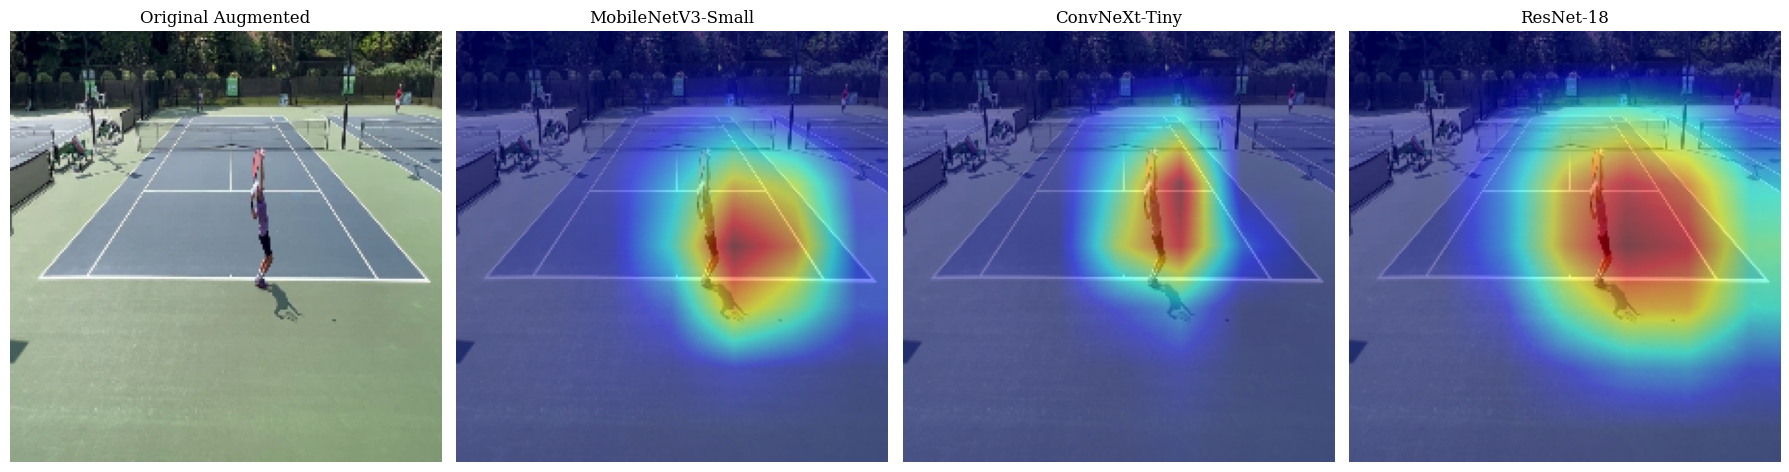

In [122]:
gradcam_plot(img_path_1, 'assets/serve_gradcam.png')

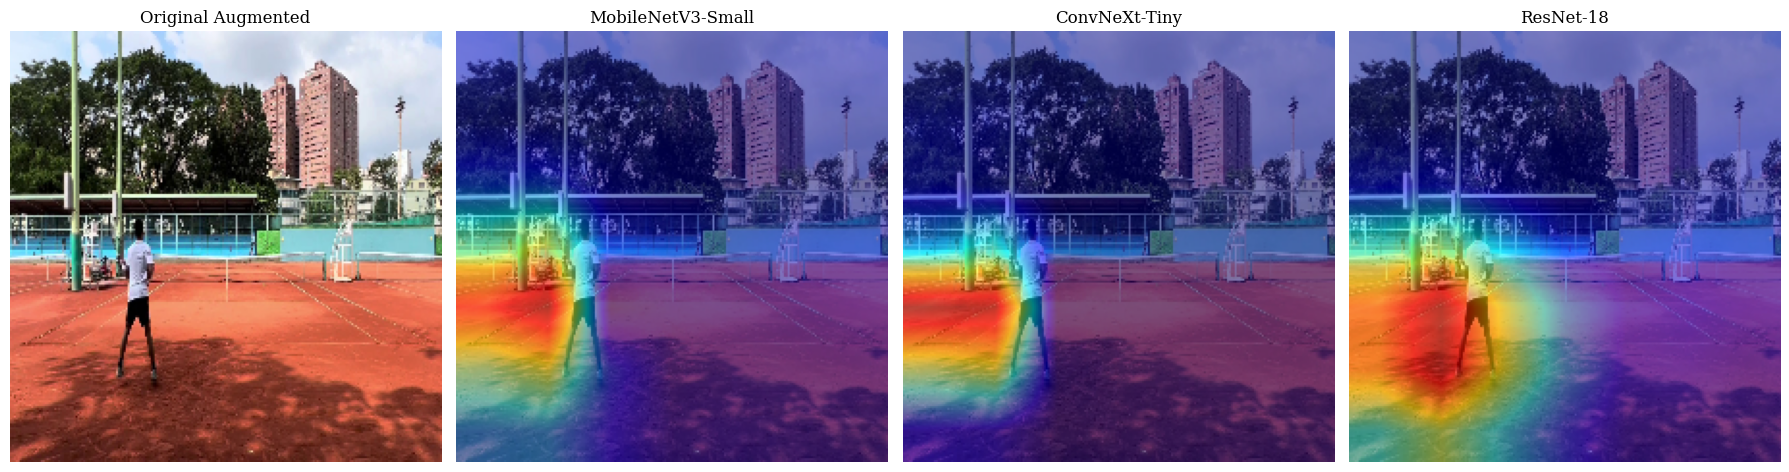

In [129]:
gradcam_plot(img_path_2, 'assets/ready_position_gradcam.png')

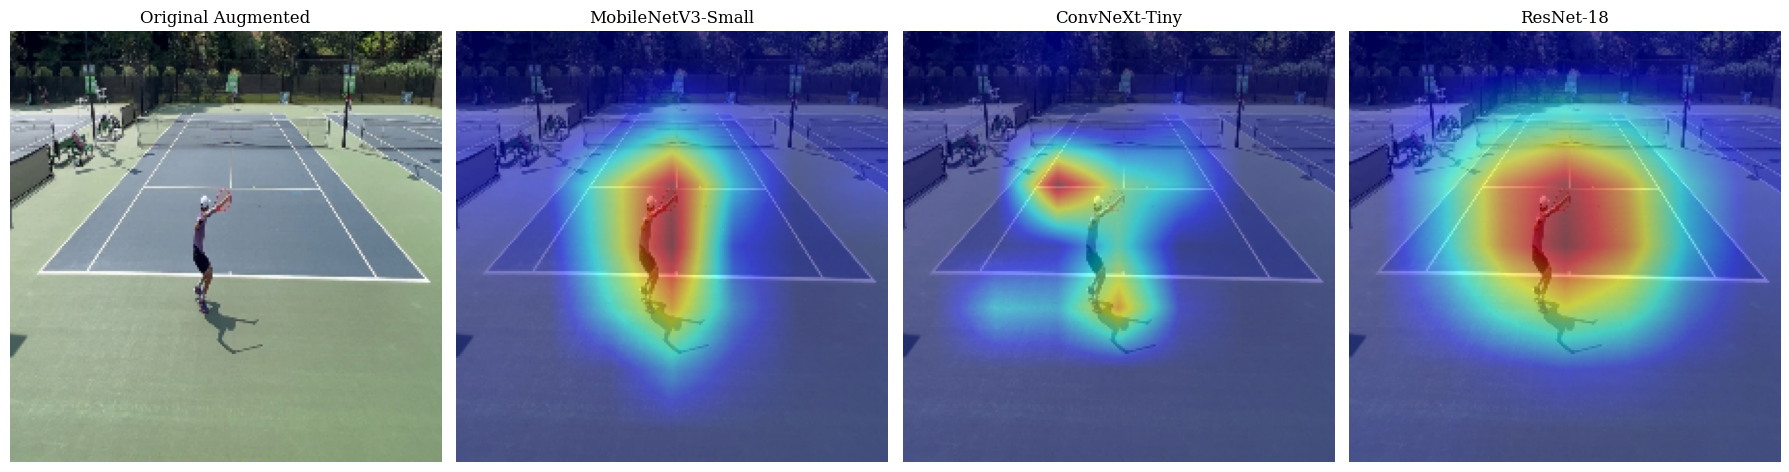

In [119]:
gradcam_plot(img_path_3, 'assets/forehand_gradcam.png')

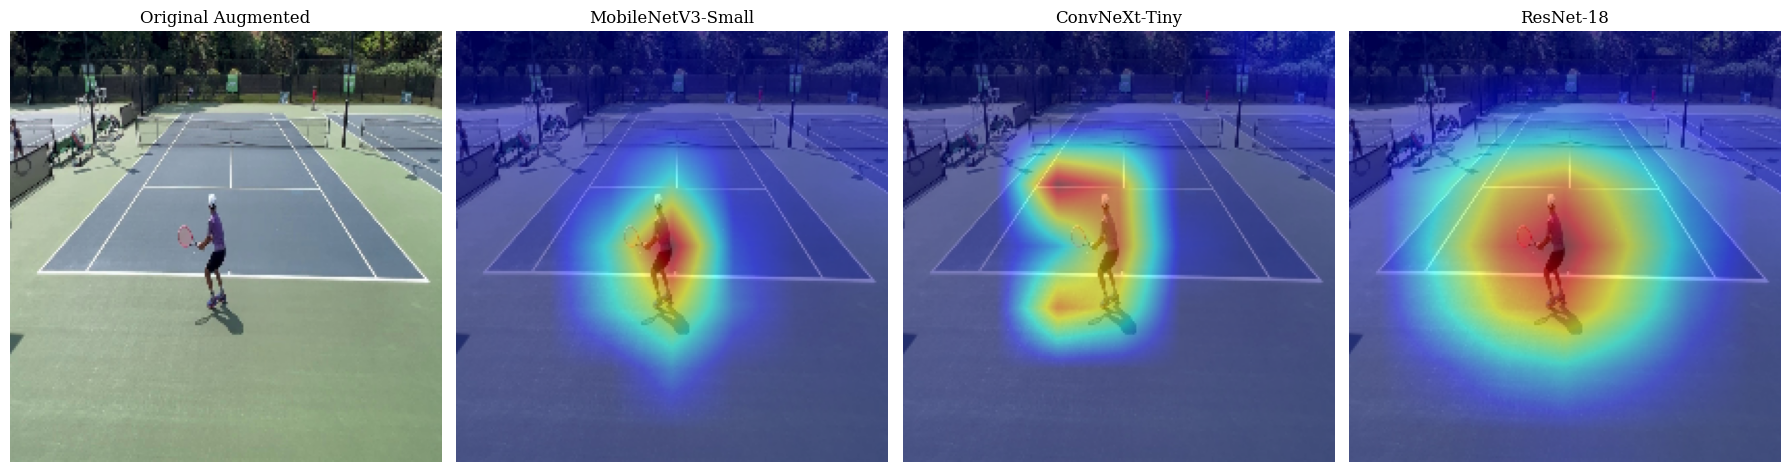

In [120]:
gradcam_plot(img_path_4, 'assets/backhand_gradcam.png')